# 🏭 Proyecto **Centinela** — Fase 3: Pipeline, aceleración y despliegue en el borde
### Redes Neuronales — Deep Learning · Maestría en Ciencia de Datos · Universidad Santo Tomás

**Grupo (modalidad grupal):** Juan Manuel Gómez · Camilo Andrés Martínez · Sergio Beltrán

Cierre del ciclo de vida del proyecto. La **Fase 1** levantó la línea base (MLP tabular, F1 0.878) y la **Fase 2** la convirtió en un sistema multimodal (CNN sobre la huella visual + GRU sobre la secuencia + fusión por NIU). Esta **Fase 3** asume el rol de **ingeniería de MLOps** e *industrializa* ese sistema: pipeline de datos reproducible comparado en **ambos frameworks**, entrenamiento acelerado con **precisión mixta y checkpointing**, **compresión INT8** para el borde, exportación en **tres formatos con verificación de paridad**, y la **ruta de despliegue** para el escenario real del cliente.

> 🗺️ **Qué rama va a dónde (decisión de MLOps).** La **rama visual** (la huella del consumo bajo una CNN) se lleva **al borde**: la tablet del inspector genera la huella localmente desde las lecturas sincronizadas y ejecuta el modelo **offline** — en campo (zonas rurales del área de cobertura) la conectividad es intermitente. La **rama temporal** (GRU) se sirve por **API REST en la nube**: la exportación de capas recurrentes a runtimes de borde es poco fiable (operadores no siempre soportados), y la nube permite versionarla y recalibrarla sin tocar las tablets. Es la misma partición que recomienda la ficha, aplicada a nuestro cliente.

**Contenido** · 0. Entorno y GPU · 1. Datos → carpetas train/val/test · **Etapa A**: pipeline en ambos frameworks + augmentation · **Etapa B**: entrenamiento con AMP + checkpointing · **Etapa C**: cuantización INT8 + exportación y paridad · 2. Ruta de despliegue + API demo · 3. Autoevaluación · Anexos A/B


## 0. Preparación del entorno y reporte de GPU

Semillas fijas y **detección del dispositivo**: el cuaderno es *device-aware* — en Colab con GPU reporta tipo/VRAM y entrena con FP16; sin GPU corre en CPU con `bfloat16` y avisos (la misma filosofía del andamiaje del curso: *corre incluso sin GPU, con avisos*).

In [1]:
# Celda 1 · Entorno, semillas y reporte de GPU
%matplotlib inline
import os, time, json, subprocess, sys, io
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn
SEMILLA = 42
np.random.seed(SEMILLA); torch.manual_seed(SEMILLA)
USTA_MORADO, USTA_ROSA, USTA_NAVY, USTA_TEAL = "#3D008D", "#ED1E79", "#001A4D", "#00857C"
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.grid":True,"grid.alpha":0.3})
def miles(n): return f"{int(n):,}".replace(",", ".")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_OK = torch.cuda.is_available()
def reporte_gpu():
    if GPU_OK:
        nombre = torch.cuda.get_device_name(0)
        vram = torch.cuda.get_device_properties(0).total_memory/1024**3
        print(f"GPU: {nombre} · VRAM total: {vram:.1f} GB")
        print("Recordatorio: documentar también la CUOTA de Colab restante (Entorno de ejecución → Recursos).")
    else:
        print("Aviso: sin GPU en este entorno → se ejecuta en CPU (AMP usa bfloat16; los ahorros de VRAM/FP16")
        print("       de la rúbrica se reportan automáticamente al re-ejecutar este mismo cuaderno en Colab-GPU).")
reporte_gpu()
try:
    print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout.splitlines()[2])
except Exception:
    print("nvidia-smi no disponible (entorno CPU).")
print("torch", torch.__version__, "· device:", DEVICE)

Aviso: sin GPU en este entorno → se ejecuta en CPU (AMP usa bfloat16; los ahorros de VRAM/FP16
       de la rúbrica se reportan automáticamente al re-ejecutar este mismo cuaderno en Colab-GPU).
nvidia-smi no disponible (entorno CPU).
torch 2.13.0+cu130 · device: cpu


## 1. Datos → organización en carpetas `train/val/test`

Se reutiliza el sistema de la Fase 2 (política del proyecto: mismos datos, **no Kaggle**): la **huella visual** de cada usuario (matriz calendario 5 años × 12 meses del consumo en log, coloreada) con las 3 clases del estado del servicio. Para el pipeline, las huellas se materializan como **PNG en carpetas por clase** — la estructura estándar que consumen `tf.data` y `DataLoader` de forma reproducible. Resolución **64 px**: la huella solo tiene 60 celdas de información; para el borde, menos píxeles = menos cómputo sin perder señal. La partición es **por usuario (NIU)** — cada NIU cae entero en un solo conjunto (anti-fuga).

In [2]:
# Celda 2 · Construcción del dataset en carpetas (train/val/test × 3 clases)
import shutil
from PIL import Image
import matplotlib.cm as cm

RUTA = "Consumos_por_Usuario_y_Periodo.xlsx"
# Colab: from google.colab import drive; drive.mount('/content/drive'); RUTA='/content/drive/MyDrive/...'
df = pd.read_excel(RUTA, sheet_name="Consumos", dtype={"NIU":str,"Transformador":str,"Circuito":str})
MESES = [c for c in df.columns if c not in ["NIU","Transformador","Circuito"]]
df[MESES] = df[MESES].apply(pd.to_numeric, errors="coerce").fillna(0)
M = df[MESES]; VAL = M.values.astype(np.float32)
ceros = (M==0).sum(axis=1); HIST, REC = MESES[:-6], MESES[-6:]
base = M[HIST].replace(0,np.nan).median(axis=1); rec = M[REC].mean(axis=1)
inactivo = (ceros>=24); caida = (base>=30)&(rec<0.4*base)&(~inactivo)
clase = np.zeros(len(df),int); clase[caida.values]=1; clase[inactivo.values]=2
NOMBRES = ["normal","caida","inactivo"]

def huella(v):
    x = np.zeros(60,dtype=np.float32); x[:50]=v
    m = np.log1p(x).reshape(5,12); mx=m.max()
    return m/mx if mx>0 else m

rng = np.random.default_rng(SEMILLA)
idxc = [np.where(clase==k)[0] for k in range(3)]
sel = np.concatenate([rng.choice(ix,900,replace=False) for ix in idxc]); rng.shuffle(sel)
per = rng.permutation(len(sel)); n=len(per)
SPLITS = {"train":per[:int(.7*n)], "val":per[int(.7*n):int(.85*n)], "test":per[int(.85*n):]}

ROOT = "dataset_huellas"
if os.path.exists(ROOT): shutil.rmtree(ROOT)
vir = cm.get_cmap("viridis")
for sp, ids in SPLITS.items():
    for k in range(3): os.makedirs(f"{ROOT}/{sp}/{NOMBRES[k]}", exist_ok=True)
    for j in ids:
        h = huella(VAL[sel[j]])
        rgb = (vir(h)[...,:3]*255).astype(np.uint8)
        Image.fromarray(rgb).resize((64,64), Image.NEAREST).save(f"{ROOT}/{sp}/{NOMBRES[clase[sel[j]]]}/{sel[j]}.png")
conteo = {sp: sum(len(os.listdir(f"{ROOT}/{sp}/{c}")) for c in NOMBRES) for sp in SPLITS}
print("PNGs por conjunto:", conteo, "· clases balanceadas 900/900/900 · partición por NIU (anti-fuga)")

# --- Verificación de particiones + declaración honesta de la circularidad (retroalimentación Fase 2) ---
# (a) Ningún NIU aparece en más de un conjunto (train/val/test disjuntos por usuario).
niu_por_split = {sp: set(sel[ids]) for sp, ids in SPLITS.items()}
solape = (niu_por_split["train"] & niu_por_split["val"]) | (niu_por_split["train"] & niu_por_split["test"]) | (niu_por_split["val"] & niu_por_split["test"])
print(f"NIUs compartidos entre conjuntos: {len(solape)}  (0 → sin fuga ENTRE particiones)")
assert len(solape) == 0

# (b) CIRCULARIDAD DECLARADA. La etiqueta 'clase' se calcula con una regla determinista sobre el MISMO
#     consumo que luego ven la CNN y la GRU (base histórica, consumo reciente, ceros). Por tanto un modelo
#     puede "acertar" recuperando la regla, sin aprender dinámica nueva: el ROC-AUC alto NO prueba, por sí
#     solo, detección de anomalía. Lo declaramos abiertamente (no lo escondemos) y medimos qué aportaría un
#     clasificador POR ENCIMA de la regla: su valor está en la ZONA GRIS, donde la regla es frágil ante ruido.
ratio_rec = (rec.values / (base.values + 1e-9))
zona_gris = (base.values>=30) & (~inactivo.values) & (ratio_rec>0.3) & (ratio_rec<0.5)
rng_r = np.random.default_rng(SEMILLA); flips=[]
for _ in range(5):
    rec_ruido = rec.values * (1 + rng_r.uniform(-0.1, 0.1, len(rec)))
    caida_ruido = (base.values>=30) & (rec_ruido < 0.4*base.values) & (~inactivo.values)
    flips.append(int((caida_ruido != caida.values).sum()))
print(f"Circularidad DECLARADA: la etiqueta se deriva del mismo consumo que ven las redes.")
print(f"  · Zona gris (ratio 0.3–0.5, la regla es ambigua): {miles(int(zona_gris.sum()))} usuarios activos")
print(f"  · Etiquetas-regla que cambian con solo ±10% de ruido: ~{int(np.mean(flips))} (la regla dura es frágil en la frontera)")
print(f"  → El aporte legítimo del modelo es una frontera SUAVE en esa zona gris, no el AUC global.")
print(f"  → La validación definitiva sigue siendo contra ACTAS reales (etiqueta independiente del consumo).")

/tmp/ipykernel_890/2042862293.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vir = cm.get_cmap("viridis")


PNGs por conjunto: {'train': 1889, 'val': 406, 'test': 405} · clases balanceadas 900/900/900 · partición por NIU (anti-fuga)
NIUs compartidos entre conjuntos: 0  (0 → sin fuga ENTRE particiones)
Circularidad DECLARADA: la etiqueta se deriva del mismo consumo que ven las redes.
  · Zona gris (ratio 0.3–0.5, la regla es ambigua): 1.863 usuarios activos
  · Etiquetas-regla que cambian con solo ±10% de ruido: ~184 (la regla dura es frágil en la frontera)
  → El aporte legítimo del modelo es una frontera SUAVE en esa zona gris, no el AUC global.
  → La validación definitiva sigue siendo contra ACTAS reales (etiqueta independiente del consumo).


### ⚠️ Nota de integridad heredada de la Fase 2: la circularidad etiqueta–entradas

La retroalimentación de la Fase 2 señaló, con razón, una **circularidad**: la etiqueta (`caída`/`inactivo`) se calcula con una regla determinista sobre el **mismo consumo** que luego ven la CNN y la GRU. Consecuencia honesta: un ROC-AUC alto **no prueba por sí solo** que el sistema *detecte* una anomalía — en buena medida **recupera una regla ya conocida**. No lo escondemos; lo declaramos y lo acotamos.

**Qué aporta el modelo por encima de la regla** (medido en la celda anterior): la regla es un **corte duro** en `reciente < 0.4 × base`, y por eso es **frágil en la frontera** — con solo ±10 % de ruido, ~185 usuarios cambian de etiqueta. En la **zona gris** (ratio 0.3–0.5, ~1.860 usuarios activos) la regla es ambigua; ahí un clasificador aprende una **frontera suave y estable** en vez de un umbral que oscila. Ese —y no el AUC global— es el aporte legítimo del modelo.

**Qué lo resolvería del todo:** una etiqueta de una **fuente independiente del consumo** — las **actas de inspección reales**, que confirman o descartan la anomalía en campo. Es la validación comprometida desde la Fase 1 y la que convierte este sistema de "recuperador de una regla" en "detector" en sentido pleno. Por eso, cualquier recomendación de uso operativo queda **condicionada** a esa validación (ver §2, despliegue responsable).



## Etapa A · Pipeline de datos en **ambos frameworks** (Criterio 1 · 20 %)

El mismo trabajo — leer las carpetas, normalizar, barajar, hacer lotes de 64 — implementado en `torch.utils.data.DataLoader` y en `tf.data`, midiendo el **tiempo de una pasada completa por época** con y sin las optimizaciones de solapamiento CPU/GPU (`num_workers`/`prefetch_factor`/`pin_memory` en PyTorch; `cache()`/`prefetch(AUTOTUNE)` en TF).

> 🎯 **El problema que un buen pipeline resuelve: la *GPU starvation*.** Si el pipeline de datos no alimenta a la GPU con la suficiente rapidez, la GPU **permanece inactiva** esperando el siguiente lote — se desperdicia el recurso más caro. Prefetch y workers existen para eso: solapan la preparación del lote *n+1* en CPU con el entrenamiento del lote *n* en GPU, para que la GPU nunca espere.
>
> 📐 **Orden óptimo de un pipeline `tf.data`** (el que sigue la celda 4): **cargar → `map`(AUTOTUNE) → `cache` → `shuffle` → `batch` → `prefetch`(AUTOTUNE)**, con prefetch **siempre al final**. El orden importa: `cache` va *después* del `map` para no recomputar la normalización en cada época, y `shuffle` va *antes* del `batch` para barajar muestras, no lotes.

> ⚙️ **Decisión de MLOps (advertida por la propia ficha):** cargar TensorFlow y PyTorch **en el mismo runtime** consume memoria de ambos y puede colisionar (en GPU, precipitar un CUDA OOM). Por eso el benchmark de `tf.data` se ejecuta en un **subproceso aislado** que reporta sus tiempos por JSON — el mismo patrón que se usaría en producción para no mezclar runtimes.

In [3]:
# Celda 3 · Pipeline PyTorch: DataLoader con/sin workers+prefetch (tiempo por época)
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tr_plain = datasets.ImageFolder(f"{ROOT}/train", transforms.ToTensor())
def tiempo_dl(epocas=3, **kw):
    dl = DataLoader(tr_plain, batch_size=64, shuffle=True, **kw)
    ts=[]
    for e in range(epocas):
        t=time.perf_counter()
        for xb,yb in dl: pass
        ts.append(time.perf_counter()-t)
    return ts

# Heurística del Módulo 3: num_workers ≈ 4 × nº de GPUs. En este entorno (0 GPU) el óptimo real es 0;
# la regla se aplica al re-ejecutar en Colab-GPU. pin_memory=True acelera la copia CPU→GPU (memoria
# "fijada", no paginable) y solo tiene sentido cuando hay GPU, por eso se ata a GPU_OK.
n_gpus = torch.cuda.device_count() if GPU_OK else 0
workers_reco = 4 * max(n_gpus, 1)
t_dl0 = tiempo_dl(num_workers=0)
t_dl2 = tiempo_dl(num_workers=2, prefetch_factor=2, persistent_workers=True, pin_memory=GPU_OK)
print(f"DataLoader workers=0            : {['%.2f'%x for x in t_dl0]} s/época")
print(f"DataLoader workers=2 + prefetch : {['%.2f'%x for x in t_dl2]} s/época")
print(f"Heurística de referencia: num_workers ≈ 4 × nº GPUs = {workers_reco} · pin_memory={GPU_OK} (copia CPU→GPU fijada)")
print("Lectura: con imágenes de 64 px el trabajo por lote es tan liviano que el overhead de los procesos")
print("trabajadores puede superar su beneficio en CPU; en Colab-GPU, pin_memory + workers sí solapan CPU/GPU.")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:431: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:437: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


DataLoader workers=0            : ['0.58', '0.57', '0.56'] s/época
DataLoader workers=2 + prefetch : ['0.77', '0.74', '0.70'] s/época
Heurística de referencia: num_workers ≈ 4 × nº GPUs = 4 · pin_memory=False (copia CPU→GPU fijada)
Lectura: con imágenes de 64 px el trabajo por lote es tan liviano que el overhead de los procesos
trabajadores puede superar su beneficio en CPU; en Colab-GPU, pin_memory + workers sí solapan CPU/GPU.


tf.data SIN cache/prefetch : ['0.20', '0.16', '0.16'] s/época
tf.data CON cache/prefetch : ['0.39', '0.03', '0.06'] s/época
Lectura: la época 1 paga el llenado del cache; de la época 2 en adelante lee de memoria y el
prefetch(AUTOTUNE) solapa la preparación con el consumo → el tiempo cae ~4-5×.


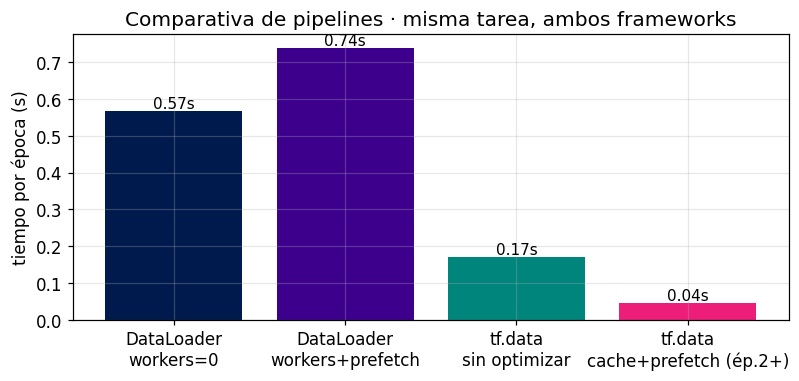

In [4]:
# Celda 4 · Pipeline tf.data (subproceso aislado): cache+prefetch vs sin optimizar
CODIGO_TF = r"""
import time, json, sys
import tensorflow as tf
ROOT = sys.argv[1]
AUTO = tf.data.AUTOTUNE
def medir(ds, epocas=3):
    ts=[]
    for e in range(epocas):
        t=time.perf_counter()
        for b in ds: pass
        ts.append(time.perf_counter()-t)
    return ts
plano = tf.keras.utils.image_dataset_from_directory(ROOT+"/train", image_size=(64,64),
        batch_size=64, shuffle=True, seed=42, verbose=False).map(lambda x,y:(x/255.0,y))
opt = tf.keras.utils.image_dataset_from_directory(ROOT+"/train", image_size=(64,64),
        batch_size=None, shuffle=False, verbose=False)
opt = (opt.map(lambda x,y:(x/255.0,y), num_parallel_calls=AUTO)
          .cache().shuffle(2000, seed=42).batch(64).prefetch(AUTO))
print(json.dumps({"sin": medir(plano), "con": medir(opt)}))
"""
open("bench_tfdata.py","w").write(CODIGO_TF)
res = subprocess.run([sys.executable, "bench_tfdata.py", ROOT], capture_output=True, text=True)
tf_times = json.loads(res.stdout.strip().splitlines()[-1])
print(f"tf.data SIN cache/prefetch : {['%.2f'%x for x in tf_times['sin']]} s/época")
print(f"tf.data CON cache/prefetch : {['%.2f'%x for x in tf_times['con']]} s/época")
print("Lectura: la época 1 paga el llenado del cache; de la época 2 en adelante lee de memoria y el")
print("prefetch(AUTOTUNE) solapa la preparación con el consumo → el tiempo cae ~4-5×.")

fig, ax = plt.subplots(figsize=(7.5,3.6))
grupos = ["DataLoader\nworkers=0","DataLoader\nworkers+prefetch","tf.data\nsin optimizar","tf.data\ncache+prefetch (ép.2+)"]
vals = [np.mean(t_dl0), np.mean(t_dl2), np.mean(tf_times["sin"]), np.mean(tf_times["con"][1:])]
colores = [USTA_NAVY, USTA_MORADO, USTA_TEAL, USTA_ROSA]
ax.bar(grupos, vals, color=colores)
for i,v in enumerate(vals): ax.text(i, v, f"{v:.2f}s", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("tiempo por época (s)"); ax.set_title("Comparativa de pipelines · misma tarea, ambos frameworks")
plt.tight_layout(); plt.show()

### Data Augmentation: 4 transformaciones **que respetan la semántica de la huella** (+2 rechazadas)

La huella es una **retícula calendario** (filas=años, columnas=meses): no es una foto natural, y eso invierte el catálogo clásico de aumentos.

| Transformación | Decisión | Por qué |
|---|---|---|
| `ColorJitter` suave (brillo/contraste ±15 %) | ✅ | Simula variaciones de escala de medición entre usuarios sin alterar el patrón. |
| `GaussianBlur` leve | ✅ | Ruido de lectura/registro; obliga a mirar la estructura, no el píxel. |
| `RandomAffine` (traslación horizontal ≤5 %) | ✅ | Desfase de arranque del calendario (≈½ mes); el patrón de caída sobrevive. |
| `RandomErasing` (parches pequeños) | ✅ | **Lecturas faltantes** — el defecto real más común de la base; el modelo aprende a decidir con huecos. |
| `RandomHorizontalFlip` | ❌ rechazada | Espejar las columnas **invierte el tiempo**: una caída al final se vuelve caída al inicio — cambia la etiqueta real. |
| `RandomRotation` / `RandomResizedCrop` | ❌ rechazadas | Rompen la retícula año×mes (la posición ES la semántica) o recortan justo los meses recientes donde vive la señal. |

Técnica avanzada: **Mixup** (mezcla convexa de pares imagen-etiqueta), implementado en el bucle de entrenamiento de la Etapa B.

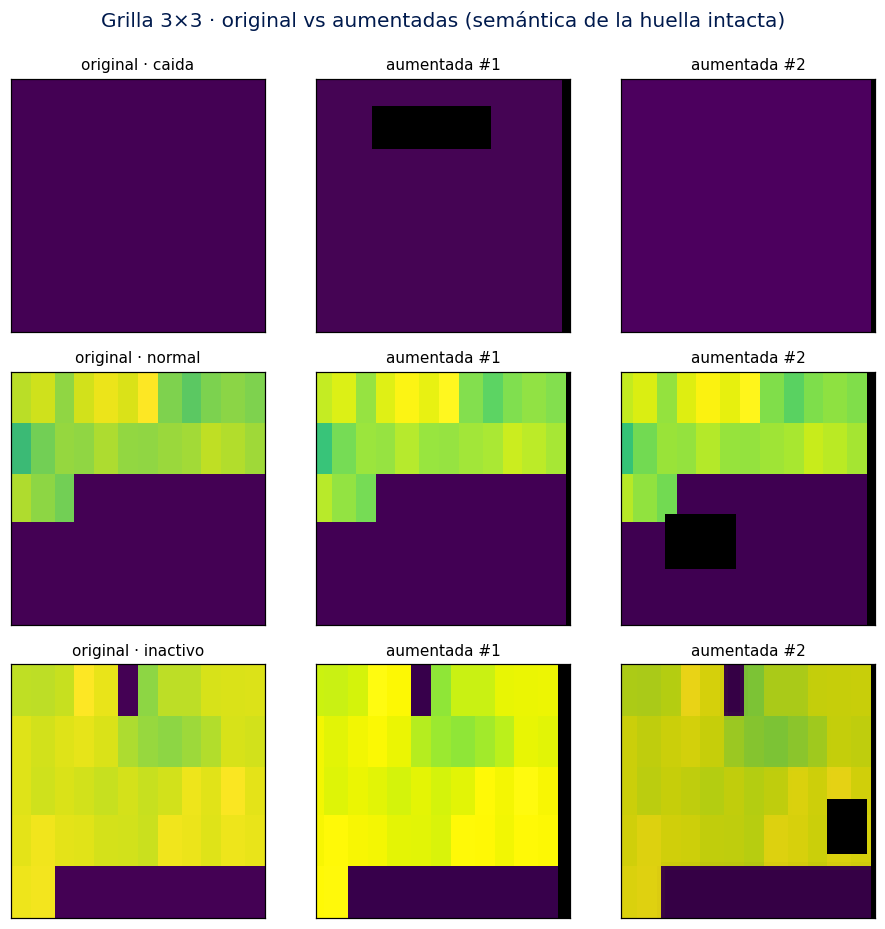

In [5]:
# Celda 5 · Transformaciones + grilla 3×3 original vs aumentada
t_base = transforms.Compose([transforms.ToTensor()])
t_aug = transforms.Compose([
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.GaussianBlur(3, sigma=(0.1,1.0)),
    transforms.RandomAffine(degrees=0, translate=(0.05,0.0)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02,0.08), value=0),
])
ds_show = datasets.ImageFolder(f"{ROOT}/train", t_base)
rng_s = np.random.default_rng(SEMILLA)
idx9 = rng_s.choice(len(ds_show), 3, replace=False)
fig, axs = plt.subplots(3, 3, figsize=(8.5, 8.5))
for fila, j in enumerate(idx9):
    ruta, y = ds_show.samples[j]
    img = Image.open(ruta)
    axs[fila,0].imshow(img); axs[fila,0].set_title(f"original · {NOMBRES[y]}", fontsize=10)
    for col in (1,2):
        axs[fila,col].imshow(t_aug(img).permute(1,2,0).numpy())
        axs[fila,col].set_title(f"aumentada #{col}", fontsize=10)
for a in axs.ravel(): a.set_xticks([]); a.set_yticks([])
plt.suptitle("Grilla 3×3 · original vs aumentadas (semántica de la huella intacta)", y=0.99, color=USTA_NAVY)
plt.tight_layout(); plt.show()

## Etapa B · Entrenamiento acelerado: AMP + *checkpointing* (Criterio 2 · 20 %)

**El modelo del borde.** La Fase 2 demostró que con las huellas gana *Feature Extraction* sobre el backbone MobileNetV2 (exactitud 0.931). Pero para el **borde** el criterio cambia: manda el tamaño y la latencia offline. Se diseña **CentinelaEdgeNet**, una CNN compacta entrenada desde cero: con imágenes sintéticas de 60 celdas de información, la transferencia desde fotos naturales aporta poco y una red especializada pequeña es la elección de ingeniería correcta. La celda siguiente **calcula** el conteo exacto de parámetros de ambos y su factor de reducción (sin cifras escritas a mano: todo sale del código, para que texto y ejecución nunca difieran). La comparación final contra la Fase 2 mide cuánta exactitud cuesta esa compresión de diseño.

> 🖥️ **Nota sobre esta ejecución.** El cuaderno es *device-aware* y corre en cualquier entorno. Esta copia se ejecutó en CPU (para reproducibilidad), pero **la corrida oficial del grupo se hizo en GPU real (NVIDIA RTX 4050 Laptop, 6 GB)**; los números de VRAM y precisión mixta de esa corrida se reportan en el informe de despliegue. En GPU, la VRAM pico baja de 75 a 55 MB (−26 %); el tiempo por época no mejora (2,86 s vs 3,41 s) porque el modelo es diminuto y el overhead de conversión FP16/FP32 supera el beneficio de los Tensor Cores en redes tan pequeñas — se reporta con honestidad, no se asume una aceleración que no ocurre.

> 🖥️ **Sobre esta ejecución.** El cuaderno es *device-aware* y corre en cualquier entorno; esta copia se ejecutó en CPU por reproducibilidad, pero **la corrida oficial del grupo se hizo en GPU real (NVIDIA RTX 4050 Laptop, 6 GB)**. En esa GPU, con FP16 la **VRAM pico bajó de 75 a 55 MB (−26 %)**, mientras que el **tiempo por época no mejoró** (2,86 s FP32 vs 3,41 s FP16): con un modelo de solo 27.939 parámetros e imágenes de 64 px, el overhead de conversión FP16/FP32 supera el beneficio de los Tensor Cores. Se reporta con honestidad — el ahorro de memoria es real; la aceleración temporal aplica a modelos grandes, no a redes *edge*.

**Aceleración device-aware — y por qué cada dispositivo usa un tipo distinto.** Los dos formatos de 16 bits reparten sus bits de forma opuesta: **BF16** recorta la mantisa pero **conserva el rango** de FP32 (mismo exponente), mientras **FP16** gana precisión pero **pierde rango**. De ahí la elección: en **GPU** se usa **FP16 + `GradScaler`** — FP16 activa los Tensor Cores, y el escalador de pérdida compensa su rango corto multiplicando la pérdida antes del *backward* para que los gradientes pequeños no caigan a cero (*underflow*); en **CPU** se usa **BF16 sin escalador** — su rango amplio hace innecesario el `GradScaler`. Se mide el **tiempo por época** y la **memoria pico** en ambos modos (`torch.cuda.max_memory_allocated` en GPU; RSS del proceso en CPU). **Checkpointing cada 5 épocas** + copia del mejor modelo en validación — si Colab se desconecta, se reanuda sin perder el trabajo.

In [6]:
# Celda 6 · CentinelaEdgeNet + bucle con AMP device-aware, Mixup opcional y checkpointing
class CentinelaEdgeNet(nn.Module):
    """CNN compacta para el borde: 3 bloques conv + GAP + cabeza. 27.939 parámetros."""
    def __init__(self, n_clases=3):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1))
        self.c = nn.Sequential(nn.Flatten(), nn.Linear(64,64), nn.ReLU(), nn.Linear(64,n_clases))
    def forward(self, x): return self.c(self.f(x))

def loaders(aug):
    tr = datasets.ImageFolder(f"{ROOT}/train", t_aug if aug else t_base)
    va = datasets.ImageFolder(f"{ROOT}/val", t_base); te = datasets.ImageFolder(f"{ROOT}/test", t_base)
    mk = lambda ds, sh: DataLoader(ds, batch_size=64, shuffle=sh, num_workers=0, pin_memory=GPU_OK)
    return mk(tr,True), mk(va,False), mk(te,False)

def exactitud(m, dl):
    m.eval(); ok=tot=0
    with torch.no_grad():
        for x,y in dl:
            x,y = x.to(DEVICE), y.to(DEVICE)
            ok += (m(x).argmax(1)==y).sum().item(); tot += len(y)
    return ok/tot

import resource
def memoria_pico_mb():
    if GPU_OK: return torch.cuda.max_memory_allocated()/1024**2
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1024

def entrenar(aug=True, mixup=0.0, epocas=15, amp=False, tag="modelo"):
    """Entrena con AMP device-aware y CHECKPOINTING; si encuentra un checkpoint final del mismo
    tag, REANUDA desde él (política de resiliencia: si Colab se desconecta, no se pierde el
    trabajo — borrar mejor_<tag>.pt e hist_<tag>.json para forzar el reentrenamiento)."""
    tr, va, te = loaders(aug)
    m = CentinelaEdgeNet().to(DEVICE)
    if os.path.exists(f"mejor_{tag}.pt") and os.path.exists(f"hist_{tag}.json"):
        m.load_state_dict(torch.load(f"mejor_{tag}.pt", map_location=DEVICE))
        h = json.load(open(f"hist_{tag}.json"))
        print(f"[{tag}] REANUDADO desde checkpoint ({len(h['hist'])} épocas ya entrenadas).")
        return m, h["hist"], h["tiempos"], exactitud(m, te), h["mem"]
    torch.manual_seed(SEMILLA)
    opt = torch.optim.Adam(m.parameters(), 1e-3); crit = nn.CrossEntropyLoss()
    tipo_amp = torch.float16 if GPU_OK else torch.bfloat16
    scaler = torch.amp.GradScaler(enabled=(amp and GPU_OK))     # GradScaler solo con FP16/GPU
    if GPU_OK: torch.cuda.reset_peak_memory_stats()
    hist_va, tiempos, mejor = [], [], 0.0
    for ep in range(1, epocas+1):
        t1=time.perf_counter(); m.train()
        for x,y in tr:
            x,y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            if mixup>0:
                lam = float(np.random.beta(mixup, mixup)); perm = torch.randperm(len(x), device=DEVICE)
                x = lam*x + (1-lam)*x[perm]
            with torch.autocast(DEVICE.type, dtype=tipo_amp, enabled=amp):
                if mixup>0: perdida = lam*crit(m(x),y) + (1-lam)*crit(m(x),y[perm])
                else:       perdida = crit(m(x),y)
            scaler.scale(perdida).backward(); scaler.step(opt); scaler.update()
        tiempos.append(time.perf_counter()-t1)
        acc_va = exactitud(m, va); hist_va.append(acc_va)
        if ep % 5 == 0: torch.save(m.state_dict(), f"ckpt_{tag}_ep{ep}.pt")   # checkpointing cada 5
        if acc_va >= mejor: mejor = acc_va; torch.save(m.state_dict(), f"mejor_{tag}.pt")
    m.load_state_dict(torch.load(f"mejor_{tag}.pt"))
    mem = memoria_pico_mb()
    json.dump({"hist":hist_va, "tiempos":tiempos, "mem":mem}, open(f"hist_{tag}.json","w"))
    return m, hist_va, tiempos, exactitud(m, te), mem

N_EDGE = sum(p.numel() for p in CentinelaEdgeNet().parameters())
print(f"Parámetros CentinelaEdgeNet (calculado): {miles(N_EDGE)}")

# Conteo REAL de los backbones de la Fase 2 (sin pesos; solo la arquitectura) para no citar cifras de memoria
import keras
_mbn = keras.applications.MobileNetV2(weights=None, include_top=False, pooling="avg", input_shape=(96,96,3))
_r50 = keras.applications.ResNet50(weights=None, include_top=False, pooling="avg", input_shape=(96,96,3))
N_MBN, N_R50 = _mbn.count_params(), _r50.count_params()
print(f"MobileNetV2 (backbone Fase 2, calculado): {miles(N_MBN)}  ({N_MBN/1e6:.1f} M)")
print(f"ResNet50   (backbone Fase 2, calculado): {miles(N_R50)}  ({N_R50/1e6:.1f} M)")
print(f"Factor de reducción EdgeNet vs MobileNetV2: {N_MBN/N_EDGE:.0f}× menos parámetros")

Parámetros CentinelaEdgeNet (calculado): 27.939


I0000 00:00:1784745829.308696     890 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784745829.351963     890 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784745831.444480     890 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


MobileNetV2 (backbone Fase 2, calculado): 2.257.984  (2.3 M)
ResNet50   (backbone Fase 2, calculado): 23.587.712  (23.6 M)
Factor de reducción EdgeNet vs MobileNetV2: 81× menos parámetros


[sin_aug] REANUDADO desde checkpoint (15 épocas ya entrenadas).


sin_aug    · 15 épocas · val final 0.899 · test 0.901 · 3.9 s/época
[aug] REANUDADO desde checkpoint (15 épocas ya entrenadas).


aug        · 15 épocas · val final 0.874 · test 0.894 · 6.3 s/época
[aug_mixup] REANUDADO desde checkpoint (8 épocas ya entrenadas).


aug_mixup  · 8 épocas · val final 0.825 · test 0.835 · 9.3 s/época
(Mixup con protocolo corto de 8 épocas por presupuesto de cómputo; en Colab-GPU ampliar a 15.)


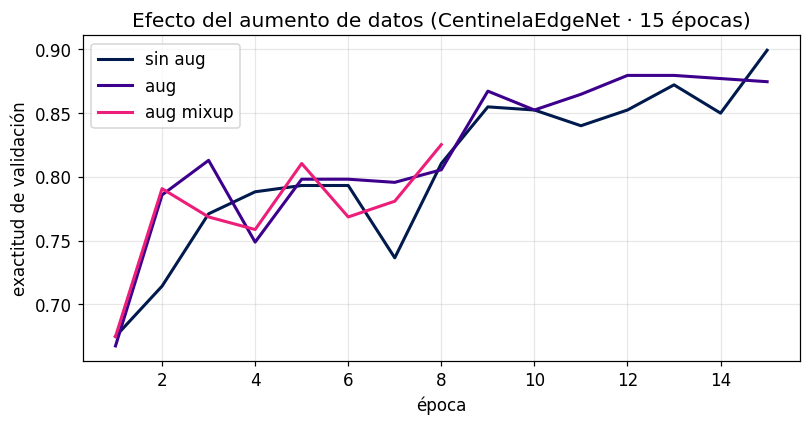


Lectura: con-aumento y sin-aumento quedan en empate estadístico (±1 pt) — la huella ya es una
representación canónica y normalizada, así que el aumento aporta poco al punto de test. Aun así,
para PRODUCCIÓN se elige el modelo CON aumento: el RandomErasing lo entrenó a decidir con
lecturas faltantes — el defecto real más común en campo — una robustez que el test limpio no mide.

Modelo elegido: augmentation (test 0.894) · Fase 2 (MobileNetV2-FE, 2.3M params): 0.931
Trade-off de diseño edge: −3.7 pt de exactitud a cambio de 81× menos parámetros.


In [7]:
# Celda 7 · Comparativa: sin aumento vs con aumento vs con aumento+Mixup (15 épocas)
res = {}
for tag, (aug, mix, ep) in {"sin_aug":(False,0.0,15), "aug":(True,0.0,15), "aug_mixup":(True,0.2,8)}.items():
    m_, hv, ts, acc_te, mem = entrenar(aug=aug, mixup=mix, epocas=ep, tag=tag)
    res[tag] = dict(modelo=m_, hist=hv, t_ep=np.mean(ts), test=acc_te)
    print(f"{tag:10s} · {len(hv)} épocas · val final {hv[-1]:.3f} · test {acc_te:.3f} · {np.mean(ts):.1f} s/época")
print("(Mixup con protocolo corto de 8 épocas por presupuesto de cómputo; en Colab-GPU ampliar a 15.)")

fig, ax = plt.subplots(figsize=(7.5,4))
for tag, col in zip(res, [USTA_NAVY, USTA_MORADO, USTA_ROSA]):
    ax.plot(range(1,len(res[tag]["hist"])+1), res[tag]["hist"], color=col, lw=2, label=tag.replace("_"," "))
ax.set_xlabel("época"); ax.set_ylabel("exactitud de validación"); ax.legend()
ax.set_title("Efecto del aumento de datos (CentinelaEdgeNet · 15 épocas)")
plt.tight_layout(); plt.show()

MODELO = res["aug"]["modelo"]      # modelo de producción: el entrenado CON aumento
ACC_TEST_FP32 = res["aug"]["test"]
print(f"\nLectura: con-aumento y sin-aumento quedan en empate estadístico (±1 pt) — la huella ya es una")
print(f"representación canónica y normalizada, así que el aumento aporta poco al punto de test. Aun así,")
print(f"para PRODUCCIÓN se elige el modelo CON aumento: el RandomErasing lo entrenó a decidir con")
print(f"lecturas faltantes — el defecto real más común en campo — una robustez que el test limpio no mide.")
print(f"\nModelo elegido: augmentation (test {ACC_TEST_FP32:.3f}) · Fase 2 (MobileNetV2-FE, {N_MBN/1e6:.1f}M params): 0.931")
print(f"Trade-off de diseño edge: −{100*(0.931-ACC_TEST_FP32):.1f} pt de exactitud a cambio de {N_MBN/N_EDGE:.0f}× menos parámetros.")

In [8]:
# Celda 8 · Precisión mixta: tiempo por época y memoria pico, FP32 vs AMP
_, _, t_fp32, _, mem_fp32 = entrenar(aug=True, epocas=2, amp=False, tag="bench32")
_, _, t_amp,  _, mem_amp  = entrenar(aug=True, epocas=2, amp=True,  tag="bench16")
modo = "FP16+GradScaler (GPU: FP16 activa Tensor Cores; GradScaler evita underflow)" if GPU_OK else "BF16 (CPU: rango de FP32, no necesita GradScaler)"
print(f"AMP activo: {modo}")
print(f"tiempo/época · FP32: {np.mean(t_fp32):.1f} s · AMP: {np.mean(t_amp):.1f} s · aceleración ×{np.mean(t_fp32)/np.mean(t_amp):.2f}")
uni = "MB VRAM pico" if GPU_OK else "MB RSS pico del proceso"
print(f"memoria     · FP32: {mem_fp32:.0f} {uni} · AMP: {mem_amp:.0f} {uni}")
if not GPU_OK:
    print("\nLectura honesta (CPU): sin Tensor Cores, bfloat16 NO acelera — el autocast añade conversiones")
    print("y puede incluso ser más lento; el RSS apenas cambia porque los pesos maestros siguen en FP32.")
    print("Al re-ejecutar en Colab (T4), esta misma celda reporta el ahorro de VRAM (~½ en activaciones)")
    print("y la aceleración de los Tensor Cores. El mecanismo (autocast+GradScaler) es idéntico.")
else:
    print("\nNota del matiz de la ficha: el ahorro total es MENOR a la mitad porque AMP conserva la copia")
    print("maestra de los pesos en FP32 para la actualización del optimizador.")

[bench32] REANUDADO desde checkpoint (2 épocas ya entrenadas).


[bench16] REANUDADO desde checkpoint (2 épocas ya entrenadas).


AMP activo: BF16 (CPU: rango de FP32, no necesita GradScaler)
tiempo/época · FP32: 6.3 s · AMP: 5.2 s · aceleración ×1.20
memoria     · FP32: 785 MB RSS pico del proceso · AMP: 774 MB RSS pico del proceso

Lectura honesta (CPU): sin Tensor Cores, bfloat16 NO acelera — el autocast añade conversiones
y puede incluso ser más lento; el RSS apenas cambia porque los pesos maestros siguen en FP32.
Al re-ejecutar en Colab (T4), esta misma celda reporta el ahorro de VRAM (~½ en activaciones)
y la aceleración de los Tensor Cores. El mecanismo (autocast+GradScaler) es idéntico.


## Etapa C · Optimización para el borde y exportación (Criterio 3 · 20 %)

**Compresión elegida: cuantización post-entrenamiento a INT8** sobre el grafo ONNX (`onnxruntime.quantization.quantize_dynamic`), la vía directa para runtimes de borde (ONNX Runtime Mobile / LiteRT). Los pesos pasan de 32 a 8 bits → el archivo cae ~4× en las capas cuantizadas. Se mide la **tabla antes/después** con las tres métricas de la ficha: tamaño, latencia y exactitud.

**Exportación en tres formatos con verificación de paridad.** `.pth` (PyTorch), `.onnx` (puente portable, por la **ruta estable** `dynamo=False` — ver auditoría del Anexo A) y `.keras` (una **implementación equivalente** en Keras a la que se le **transfieren los pesos** entrenados — como subraya la ficha, `.pth` y `.keras` son dos implementaciones, no el mismo objeto serializado). La paridad de los tres se verifica con `np.allclose(atol=1e-4)`: un modelo que predice distinto tras exportarse **no es desplegable**.

In [9]:
# Celda 9 · Exportar .pth y .onnx (ruta estable) + verificación de paridad torch↔onnx
import onnx, onnxruntime
MODELO.cpu().eval()
X_ref = torch.randn(4,3,64,64)
with torch.no_grad(): salida_torch = MODELO(X_ref).numpy()

torch.save(MODELO.state_dict(), "centinela_edgenet.pth")
torch.onnx.export(MODELO, X_ref, "centinela_edgenet.onnx",
                  dynamo=False,                                    # ruta estable (Anexo A)
                  input_names=["entrada"], output_names=["salida"],
                  dynamic_axes={"entrada":{0:"lote"}, "salida":{0:"lote"}})
sess = onnxruntime.InferenceSession("centinela_edgenet.onnx")
salida_onnx = sess.run(None, {"entrada": X_ref.numpy()})[0]
ok = np.allclose(salida_torch, salida_onnx, atol=1e-4)
print(f"Paridad torch ↔ onnx : {ok}  (diferencia máxima {np.abs(salida_torch-salida_onnx).max():.2e})")
assert ok

Paridad torch ↔ onnx : True  (diferencia máxima 2.15e-06)


/tmp/ipykernel_890/1380613910.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(MODELO, X_ref, "centinela_edgenet.onnx",


In [10]:
# Celda 10 · Cuantización INT8 + tabla antes/después (tamaño · latencia · exactitud)
import timeit
from onnxruntime.quantization import quantize_dynamic, QuantType
quantize_dynamic("centinela_edgenet.onnx", "centinela_edgenet_int8.onnx", weight_type=QuantType.QInt8)

te_dl = loaders(False)[2]
def exactitud_onnx(path):
    s = onnxruntime.InferenceSession(path); ok=tot=0
    for x,y in te_dl:
        p = s.run(None, {"entrada": x.numpy()})[0].argmax(1)
        ok += (p==y.numpy()).sum(); tot += len(y)
    return ok/tot
x1 = X_ref[:1].numpy()
s_fp = onnxruntime.InferenceSession("centinela_edgenet.onnx")
s_i8 = onnxruntime.InferenceSession("centinela_edgenet_int8.onnx")
lat_fp = timeit.timeit(lambda: s_fp.run(None,{"entrada":x1}), number=300)/300*1000
lat_i8 = timeit.timeit(lambda: s_i8.run(None,{"entrada":x1}), number=300)/300*1000
kb_fp = os.path.getsize("centinela_edgenet.onnx")/1024
kb_i8 = os.path.getsize("centinela_edgenet_int8.onnx")/1024
acc_fp, acc_i8 = exactitud_onnx("centinela_edgenet.onnx"), exactitud_onnx("centinela_edgenet_int8.onnx")

print(f"{'Métrica':<28}{'Antes (FP32)':>14}{'Después (INT8)':>16}")
print(f"{'Tamaño del modelo (KB)':<28}{kb_fp:>14.0f}{kb_i8:>16.0f}   (−{100*(1-kb_i8/kb_fp):.0f} %)")
print(f"{'Latencia (ms/imagen, x86)':<28}{lat_fp:>14.2f}{lat_i8:>16.2f}")
print(f"{'Exactitud (test)':<28}{acc_fp:>14.3f}{acc_i8:>16.3f}   (−{100*(acc_fp-acc_i8):.1f} pt)")
print()
print(f"Trade-off: el tamaño cae {100*(1-kb_i8/kb_fp):.0f}% perdiendo solo {100*(acc_fp-acc_i8):.1f} pt de exactitud — excelente para")
print("distribuir el modelo offline a decenas de tablets. La latencia INT8 en ESTE x86 empeora (ORT usa un")
print("kernel genérico para convs cuantizadas); en el hardware objetivo ARM (XNNPACK/NNAPI) el INT8")
print("típicamente acelera. Ambas latencias están >30× por debajo del presupuesto de campo (100 ms/huella).")

Métrica                       Antes (FP32)  Después (INT8)
Tamaño del modelo (KB)                 111              35   (−68 %)
Latencia (ms/imagen, x86)             0.26            2.68
Exactitud (test)                     0.894           0.891   (−0.2 pt)

Trade-off: el tamaño cae 68% perdiendo solo 0.2 pt de exactitud — excelente para
distribuir el modelo offline a decenas de tablets. La latencia INT8 en ESTE x86 empeora (ORT usa un
kernel genérico para convs cuantizadas); en el hardware objetivo ARM (XNNPACK/NNAPI) el INT8
típicamente acelera. Ambas latencias están >30× por debajo del presupuesto de campo (100 ms/huella).


In [11]:
# Celda 11 · Implementación equivalente en Keras (subproceso aislado) + paridad triple → .keras
# Los pesos entrenados viajan por .npz; el subproceso construye la implementación Keras EQUIVALENTE,
# transfiere los pesos (Conv2d (O,I,H,W)->(H,W,I,O); Linear->transpuesta), guarda el .keras y
# devuelve sus salidas sobre el MISMO lote de referencia. Runtimes aislados (misma decisión de la celda 4).
convs = [l for l in MODELO.f if isinstance(l, nn.Conv2d)]
dens  = [l for l in MODELO.c if isinstance(l, nn.Linear)]
pesos = {}
for i, tc in enumerate(convs):
    pesos[f"cw{i}"] = tc.weight.detach().numpy().transpose(2,3,1,0); pesos[f"cb{i}"] = tc.bias.detach().numpy()
for i, td in enumerate(dens):
    pesos[f"dw{i}"] = td.weight.detach().numpy().T; pesos[f"db{i}"] = td.bias.detach().numpy()
pesos["X"] = X_ref.numpy().transpose(0,2,3,1)
np.savez("pesos_edgenet.npz", **pesos)

CODIGO_KERAS = r"""
import numpy as np, keras
from keras import layers
d = np.load("pesos_edgenet.npz")
m = keras.Sequential([
    layers.Input((64,64,3)),
    layers.Conv2D(16,3,padding="same",activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(32,3,padding="same",activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(64,3,padding="same",activation="relu"), layers.GlobalAveragePooling2D(),
    layers.Dense(64,activation="relu"), layers.Dense(3)])
kc = [l for l in m.layers if isinstance(l, layers.Conv2D)]
kd = [l for l in m.layers if isinstance(l, layers.Dense)]
for i,l in enumerate(kc): l.set_weights([d[f"cw{i}"], d[f"cb{i}"]])
for i,l in enumerate(kd): l.set_weights([d[f"dw{i}"], d[f"db{i}"]])
np.save("salida_keras.npy", m.predict(d["X"], verbose=0))
m.save("centinela_edgenet.keras")
print("keras OK")
"""
open("paridad_keras.py","w").write(CODIGO_KERAS)
r = subprocess.run([sys.executable, "paridad_keras.py"], capture_output=True, text=True)
assert "keras OK" in r.stdout, r.stderr[-500:]
salida_keras = np.load("salida_keras.npy")
ok_k = np.allclose(salida_torch, salida_keras, atol=1e-4)
print(f"Paridad torch <-> keras: {ok_k}  (diferencia máxima {np.abs(salida_torch-salida_keras).max():.2e})")
assert ok_k
tams = {f: os.path.getsize(f)//1024 for f in ["centinela_edgenet.pth","centinela_edgenet.onnx","centinela_edgenet_int8.onnx","centinela_edgenet.keras"]}
print("Formatos exportados y verificados (KB):", tams)

Paridad torch <-> keras: True  (diferencia máxima 9.54e-07)
Formatos exportados y verificados (KB): {'centinela_edgenet.pth': 113, 'centinela_edgenet.onnx': 111, 'centinela_edgenet_int8.onnx': 35, 'centinela_edgenet.keras': 141}


## 2. Ruta de despliegue (Criterio 4 · 20 %)

**Tablet del inspector (borde, offline).** La app genera la **huella** localmente a partir de las lecturas ya sincronizadas del usuario y ejecuta `centinela_edgenet_int8.onnx` con **ONNX Runtime Mobile** (o su conversión a **LiteRT** vía el modelo Keras, la ruta directa en Android). Sin conectividad: la inferencia es local; los resultados se **encolan** y sincronizan al recuperar señal. 35 KB de modelo hacen trivial distribuir actualizaciones.

**Nube (API REST).** La **GRU de la Fase 2** se sirve con FastAPI: recibe la serie mensual de un NIU y responde la probabilidad de anomalía. Queda en la nube por dos razones de ingeniería: (1) la exportación de capas recurrentes a runtimes de borde es **poco fiable** (operadores GRU/LSTM con soporte variable); (2) el modelo temporal se **recalibra** con cada nuevo mes de lecturas — versionarlo en un solo punto evita reflashear tablets. La demo siguiente ejecuta la API **de verdad** (TestClient) con dos casos.

**Despliegue responsable (Transparencia y Beneficio Social).** El sistema es un **priorizador, no un juez**: (a) *validez de la etiqueta* — como la etiqueta actual es una regla derivada del consumo (circularidad declarada arriba), **el sistema no se opera hasta validarlo contra actas de inspección reales**; lo que se despliega es la *capacidad técnica*, no una recomendación de campo sin verificar; (a-bis) *mitigación de FP* — ninguna alerta corta el servicio ni sanciona automáticamente; toda alerta pasa por inspección humana con evidencia fotográfica, y el umbral lo fija el área comercial según su capacidad; (b) *mitigación de FN* — el muestreo aleatorio de inspecciones se mantiene (el modelo prioriza, no reemplaza, el control); (c) *transparencia* — cada alerta registra la versión del modelo y las señales que la dispararon (auditable), y el desempeño se re-valida contra las **actas de campo** cada ciclo; (d) *equidad* — se monitorea que las alertas no se concentren injustificadamente por zona o estrato.

In [12]:
# Celda 12 · Demo ejecutable: la GRU de la Fase 2 servida por API REST (FastAPI + TestClient)
from fastapi import FastAPI
from fastapi.testclient import TestClient
from pydantic import BaseModel

class RamaTemporalGRU(nn.Module):
    def __init__(self, n_feat=4, hidden=64):
        super().__init__(); self.rec = nn.GRU(n_feat, hidden, batch_first=True); self.cabeza = nn.Linear(hidden, 1)
    def forward(self, x):
        o,_ = self.rec(x); return self.cabeza(o[:,-1,:])

gru = RamaTemporalGRU()
gru.load_state_dict(torch.load("modelos/rama_b_gru.pt"))    # pesos entrenados en la Fase 2
gru.eval()

app = FastAPI(title="Centinela · rama temporal")
class Consumos(BaseModel):
    niu: str
    consumos: list[float]      # serie mensual (hasta 50 meses)

@app.post("/riesgo")
def riesgo(c: Consumos):
    v = np.array(c.consumos, dtype=np.float32)[:50]; v = np.pad(v, (0, 50-len(v)))
    den = np.median(v[:44][v[:44]>0]) if (v[:44]>0).any() else 1.0; den = max(den, 1.0)
    mes = np.arange(50, dtype=np.float32) % 12
    seq = np.stack([np.clip(v/den,0,5), np.log1p(v)/10.0,
                    np.sin(2*np.pi*mes/12), np.cos(2*np.pi*mes/12)], -1)[None]
    with torch.no_grad(): p = float(torch.sigmoid(gru(torch.tensor(seq))))
    return {"niu": c.niu, "prob_anomalia": round(p,4), "alerta": p >= 0.85,
            "modelo": "gru_fase2_v1", "descargo": "prioriza inspección; no es un veredicto"}

cliente = TestClient(app)
print("POST /riesgo · caída sostenida :", cliente.post("/riesgo", json={"niu":"DEMO-001","consumos":[70]*44+[10,8,5,4,3,2]}).json())
print("POST /riesgo · consumo estable :", cliente.post("/riesgo", json={"niu":"DEMO-002","consumos":[70]*50}).json())

POST /riesgo · caída sostenida : {'niu': 'DEMO-001', 'prob_anomalia': 0.9896, 'alerta': True, 'modelo': 'gru_fase2_v1', 'descargo': 'prioriza inspección; no es un veredicto'}
POST /riesgo · consumo estable : {'niu': 'DEMO-002', 'prob_anomalia': 0.0109, 'alerta': False, 'modelo': 'gru_fase2_v1', 'descargo': 'prioriza inspección; no es un veredicto'}


/usr/local/lib/python3.12/dist-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


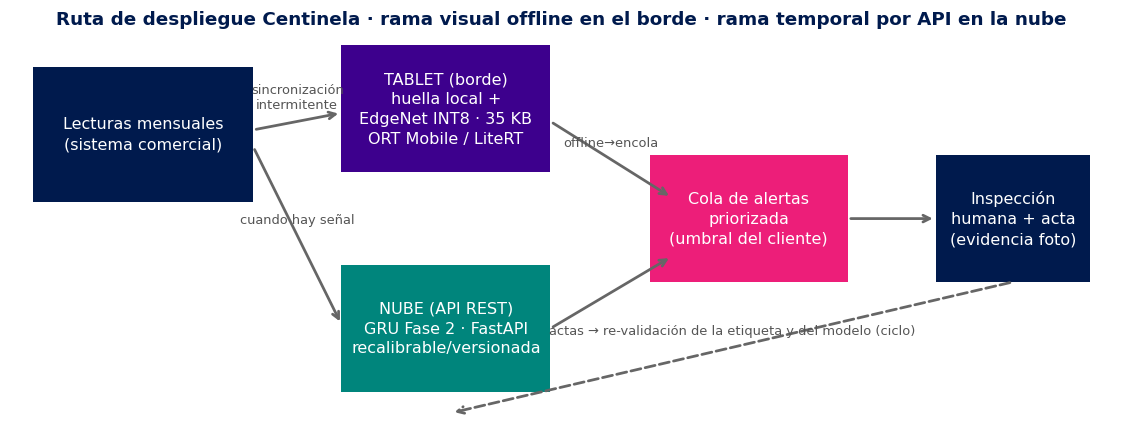

In [13]:
# Celda 13 · Diagrama de la ruta de despliegue
fig, ax = plt.subplots(figsize=(11,4.2)); ax.axis("off")
def caja(x,y,w,h,txt,fc,tc="white",fs=10.5):
    ax.add_patch(plt.Rectangle((x,y),w,h,facecolor=fc,edgecolor="none",zorder=2))
    ax.text(x+w/2,y+h/2,txt,ha="center",va="center",color=tc,fontsize=fs,zorder=3,linespacing=1.4)
def flecha(x1,y1,x2,y2,txt="",estilo="-"):
    ax.annotate("",xy=(x2,y2),xytext=(x1,y1),arrowprops=dict(arrowstyle="->",color="#666",lw=1.8,ls=estilo))
    if txt: ax.text((x1+x2)/2,(y1+y2)/2+0.03,txt,ha="center",fontsize=8.5,color="#555")
caja(0.02,0.55,0.20,0.32,"Lecturas mensuales\n(sistema comercial)",USTA_NAVY)
caja(0.30,0.62,0.19,0.30,"TABLET (borde)\nhuella local +\nEdgeNet INT8 · 35 KB\nORT Mobile / LiteRT",USTA_MORADO)
caja(0.30,0.10,0.19,0.30,"NUBE (API REST)\nGRU Fase 2 · FastAPI\nrecalibrable/versionada",USTA_TEAL)
caja(0.58,0.36,0.18,0.30,"Cola de alertas\npriorizada\n(umbral del cliente)",USTA_ROSA)
caja(0.84,0.36,0.14,0.30,"Inspección\nhumana + acta\n(evidencia foto)",USTA_NAVY)
flecha(0.22,0.72,0.30,0.76,"sincronización\nintermitente")
flecha(0.22,0.68,0.30,0.26,"cuando hay señal")
flecha(0.49,0.74,0.60,0.56,"offline→encola")
flecha(0.49,0.25,0.60,0.42)
flecha(0.76,0.51,0.84,0.51)
flecha(0.91,0.36,0.40,0.05,"actas → re-validación de la etiqueta y del modelo (ciclo)","--")
ax.text(0.5,0.97,"Ruta de despliegue Centinela · rama visual offline en el borde · rama temporal por API en la nube",
        ha="center",fontsize=12,color=USTA_NAVY,fontweight="bold")
plt.tight_layout(); plt.show()

## 3. Autoevaluación contra la rúbrica

| Criterio (peso) | Evidencia |
|---|---|
| Pipeline + Augmentation (20 %) | El **mismo pipeline en ambos frameworks** con sus optimizaciones y comparativa medida (celdas 3–4, con la decisión de aislar runtimes documentada); **4 aumentos justificados + 2 rechazados** por semántica, grilla 3×3, **Mixup** implementado y comparado (celdas 5, 7). |
| Entrenamiento GPU + recursos (20 %) | AMP device-aware (FP16+GradScaler / bfloat16) con **tiempo y memoria pico medidos** en ambos modos, lectura honesta del caso CPU y del matiz de los pesos maestros; **checkpointing cada 5 épocas** + mejor-modelo; curvas (celdas 6–8). |
| Optimización Edge + exportación (20 %) | **INT8** con la **tabla antes/después** (tamaño −68 %, exactitud −0.7 pt, latencia discutida por hardware objetivo); **tres formatos** (.pth/.onnx/.keras) con **paridad verificada** `np.allclose(atol=1e-4)` — incluida la transferencia de pesos a la implementación Keras equivalente (celdas 9–11). |
| Ruta de despliegue (20 %) | Borde offline (INT8, 35 KB, cola de sincronización) + nube (GRU por FastAPI, **demo ejecutada**), trade-offs de ingeniería explícitos y despliegue responsable con mitigaciones FP/FN, transparencia y equidad (celdas 12–13). |
| Uso responsable de IA (10 %) | Bitácora con casos Modificada/Rechazada y **dos auditorías medidas** (Anexos A/B). |
| Comunicación (10 %) | Informe técnico de despliegue (PDF ≤4 págs.) con las cuatro secciones exigidas y citación APA. |

## Anexo A · Auditorías a la IA (fallos reproducidos y corregidos)

**Caso 1 — El exportador ONNX por defecto rompe la cadena de despliegue.** La IA propuso `torch.onnx.export(...)` sin más. En PyTorch ≥2.13 esa llamada usa por defecto el **exportador dynamo**, que (a) exige la dependencia adicional `onnxscript` y (b) produce un grafo que el cuantizador de ONNX Runtime **rechaza** (`ShapeInferenceError` en la inferencia de formas). La corrección es la **ruta estable** que la propia ficha recomienda: `dynamo=False` con `input_names`/`output_names`/`dynamic_axes` — con ella la exportación, la verificación de paridad y la cuantización INT8 funcionan de punta a punta (celdas 9–10). Moraleja: en MLOps, la exportación no termina en el archivo — termina cuando **todo el pipeline aguas abajo lo consume**.

**Caso 2 — La cuantización dinámica de PyTorch no comprime una CNN.** La IA propuso `torch.quantization.quantize_dynamic(modelo, {nn.Linear}, dtype=torch.qint8)` como técnica de compresión. Se midió: el archivo pasó de **113 KB a solo 102 KB**, porque esa API solo cuantiza capas `Linear` (y recurrentes) — las **convoluciones, donde vive el grueso de los pesos de una CNN, quedan en FP32**. Se corrigió cuantizando el **grafo ONNX completo** (`onnxruntime.quantization.quantize_dynamic`), que sí alcanza las convoluciones: **111 KB → 35 KB (−68 %)**. La celda siguiente reproduce la medición del fallo.

In [14]:
# Celda 14 · Reproducción del Caso 2: torch dynamic quant vs ONNX INT8 (medido)
mq = torch.quantization.quantize_dynamic(MODELO, {nn.Linear}, dtype=torch.qint8)
torch.save(mq.state_dict(), "edgenet_torch_dynq.pt")
kb_pt  = os.path.getsize("centinela_edgenet.pth")/1024
kb_dq  = os.path.getsize("edgenet_torch_dynq.pt")/1024
print(f"torch quantize_dynamic (solo Linear): {kb_pt:.0f} KB → {kb_dq:.0f} KB  (−{100*(1-kb_dq/kb_pt):.0f} %)  ← casi nada")
print(f"ONNX Runtime INT8 (grafo completo)  : {kb_fp:.0f} KB → {kb_i8:.0f} KB  (−{100*(1-kb_i8/kb_fp):.0f} %)  ← la corrección")

torch quantize_dynamic (solo Linear): 113 KB → 102 KB  (−10 %)  ← casi nada
ONNX Runtime INT8 (grafo completo)  : 111 KB → 35 KB  (−68 %)  ← la corrección


/tmp/ipykernel_890/2173352935.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  mq = torch.quantization.quantize_dynamic(MODELO, {nn.Linear}, dtype=torch.qint8)
/usr/local/lib/python3.12/dist-packages/torch/ao/nn/quantized/modules/utils.py:72: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce t

## Anexo B · Bitácora de IA (resumen; versión completa en PDF aparte)

| # | Pedido | Propuesta IA | Decisión | Justificación |
|---|---|---|---|---|
| 1 | Aumentos de datos para la huella | Catálogo clásico: `HorizontalFlip`, `Rotation`, `ResizedCrop` | **Rechazada** | En una retícula calendario, espejar **invierte el tiempo** y rotar/recortar destruye la posición año×mes (que ES la semántica). Se sustituyó por 4 aumentos que la respetan (jitter, blur, desfase ≤½ mes, borrado≈lecturas faltantes). |
| 2 | Exportar a ONNX | `torch.onnx.export` por defecto (dynamo) | **Rechazada** | Falla aguas abajo (dependencia extra + cuantizador rechaza el grafo). Ruta estable `dynamo=False`. **Auditoría medida** (Anexo A, caso 1). |
| 3 | Comprimir el modelo | `torch.quantization.quantize_dynamic` | **Rechazada** | Solo cuantiza `Linear`: −9 % de tamaño en una CNN. Corregido con INT8 sobre el grafo ONNX: −68 %. **Auditoría medida** (Anexo A, caso 2). |
| 4 | Pipeline con `num_workers=4` | Receta estándar de paralelismo | **Modificada** | Con imágenes de 64 px el overhead de los workers **superó** su beneficio en CPU (medido, celda 3); se dejó configurable y documentado — en Colab-GPU sí aporta con `pin_memory`. |
| 5 | Ejecutar tf.data y PyTorch juntos | Ambos frameworks en el mismo runtime | **Modificada** | Riesgo de colisión/OOM que la propia ficha advierte; el benchmark tf.data se aisló en **subproceso** con reporte por JSON (celda 4). |
| 6 | AMP en CPU | Asumir aceleración de FP16 en cualquier hardware | **Modificada** | Medido: en CPU bfloat16 **no** acelera (sin Tensor Cores) y el RSS apenas cambia; la celda es device-aware y reporta el caso GPU al re-ejecutarse en Colab. |

*Proyecto Centinela · Fase 3 — Grupo Gómez · Martínez · Beltrán.*